In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))

os.environ.setdefault(
    "DJANGO_SETTINGS_MODULE",
    "FinantialEv_v1.settings"
)

os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"

import django
django.setup()

print(PROJECT_ROOT)


e:\Users\jmartin\Desktop\PricingProjects\EvaluadorFinanciero_v1\FinantialEv_v1


In [ ]:
import numpy as np

from Backend.dtos.Project import Project
from Backend.dtos.FinancialVariables import FinancialVariables
from Backend.services.ml_services import predict_vlr_mbps
from Backend.services.optimize_service import PricingOptimizer
from Backend.services.financial_variable_service import FinancialVariableService
from Backend.services.financial_engine import financial_engine

variables : FinancialVariables = FinancialVariableService.get_variables()

capacities = capacities = np.arange(1, 10000)

predicted = []
floor = []

floor_margin = []
predicted_margin = []

for cap in capacities:
    project = Project(
        capacity_mbps=cap,
        contract_time=12,
        initial_income=0
    )
    prediction = predict_vlr_mbps(cap)
    price_monthly = prediction * cap

    # Despejar sensibilidad
    capex = financial_engine.calculate_capex(project, variables)
    opex = financial_engine.calculate_opex(project, variables)

    sensitivity = (
        price_monthly * project.contract_time
        / ((capex + opex * project.contract_time) * variables.margin_factor)
    )

    result = financial_engine.evaluate_project(
        project,
        variables,
        sensitivity
    )
    predicted_margin.append(result.margin * 100)

    result_pre = PricingOptimizer.find_floor(
        project,
        variables
    )

    predicted.append(prediction)
    floor.append(result_pre.price_per_mbps)
    floor_margin.append(result_pre.margin * 100)

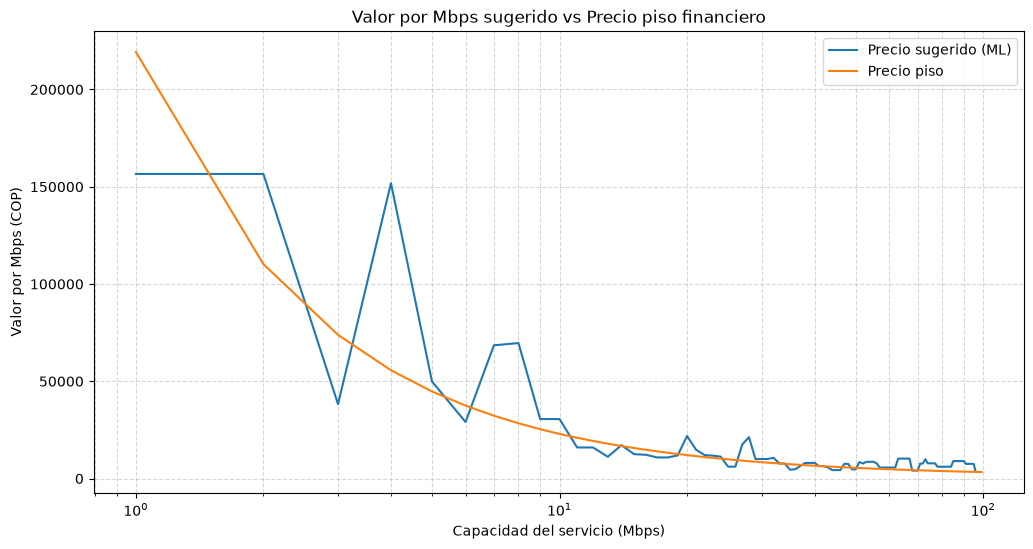

In [7]:
from matplotlib import  pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(capacities, predicted, label="Precio sugerido (ML)")
plt.plot(capacities, floor, label="Precio piso")
plt.xscale("log")
plt.legend()
plt.grid()
plt.title("Valor por Mbps sugerido vs Precio piso financiero")
plt.xlabel("Capacidad del servicio (Mbps)")
plt.ylabel("Valor por Mbps (COP)")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)

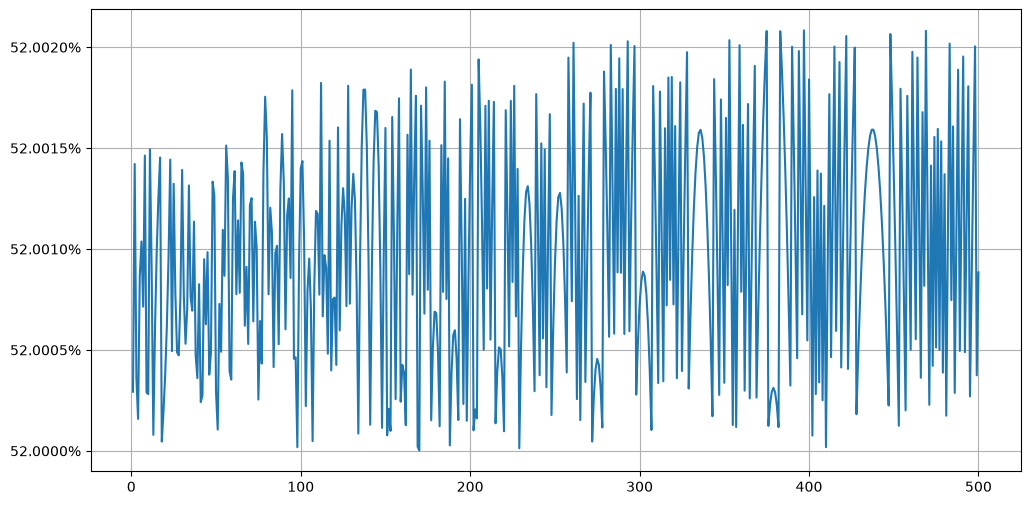

In [4]:
from matplotlib import  pyplot as plt
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(12,6))

ax.plot(capacities, floor_margin)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f"{y:.4f}%")
)

plt.grid(True)
plt.show()

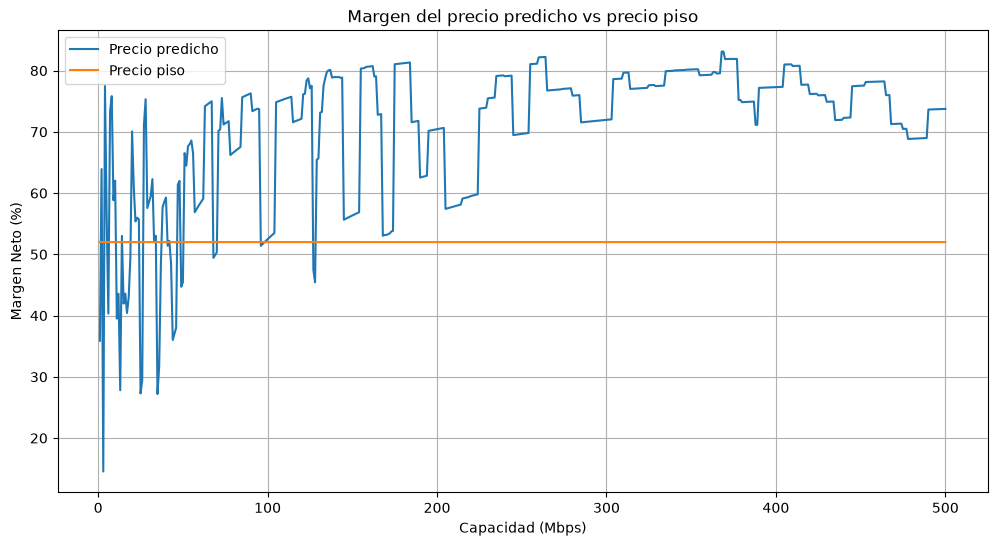

In [5]:
plt.figure(figsize=(12,6))

plt.plot(capacities, predicted_margin, label="Precio predicho")
plt.plot(capacities, floor_margin, label="Precio piso")

plt.xlabel("Capacidad (Mbps)")
plt.ylabel("Margen Neto (%)")
plt.title("Margen del precio predicho vs precio piso")

plt.legend()
plt.grid(True)

plt.gca().ticklabel_format(style="plain", axis="y", useOffset=False)

plt.show()